# **Machine Learning Homework** - Combining Evolutionary Learning, Active Learning and Ensemble Learning to solve the Higgs Bozon Detection
MARCELINO Auriane

## Sommaire
- [I - Preprocessing](#i---dataset-preprocessing)
    - [1. Import](#1-import-csv-file)
    - [2. Delete columns](#2-delete-superfluous-columns)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## I - Dataset preprocessing

### 1. Import CSV file

In [ ]:
atlas = pd.read_csv('atlas-higgs.csv')
# I create a copy of the data to work on it, and I keep the original one safe to avoid re-importing it if there is a problem
data = atlas.copy()
print(data.shape)
print(data.dtypes)
data.head()

(818238, 35)
EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality         float64
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt             float64
PRI_jet_lead

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


### 2. Delete superfluous columns

We delete some columns that are not usefull

In [5]:
del(data['EventId'])
del(data['Weight'])
del(data['KaggleSet'])
del(data['KaggleWeight'])

### 3. Check for missing values

In [20]:
print(data.isnull().sum())

DER_mass_MMC                   0
DER_mass_transverse_met_lep    0
DER_mass_vis                   0
DER_pt_h                       0
DER_deltaeta_jet_jet           0
DER_mass_jet_jet               0
DER_prodeta_jet_jet            0
DER_deltar_tau_lep             0
DER_pt_tot                     0
DER_sum_pt                     0
DER_pt_ratio_lep_tau           0
DER_met_phi_centrality         0
DER_lep_eta_centrality         0
PRI_tau_pt                     0
PRI_tau_eta                    0
PRI_tau_phi                    0
PRI_lep_pt                     0
PRI_lep_eta                    0
PRI_lep_phi                    0
PRI_met                        0
PRI_met_phi                    0
PRI_met_sumet                  0
PRI_jet_num                    0
PRI_jet_leading_pt             0
PRI_jet_leading_eta            0
PRI_jet_leading_phi            0
PRI_jet_subleading_pt          0
PRI_jet_subleading_eta         0
PRI_jet_subleading_phi         0
PRI_jet_all_pt                 0
Label     

There is no null values in any column so we don't need to make any changes about that.

### 3. Transform label

We simplify the *Label* column, the value by 1 if it's a 's' (for 'signal'), and 0 if it's a 'b' (for 'background')

In [6]:
data['Label'] = data['Label'].apply(lambda x: 1 if x == 's' else 0)

### 4. Separate the output

I separate the output to make some checks after (I do it before checking outlier because if I do it after, the outlier graph can plot 30 columns but we have 31 with the Label column)

In [16]:
X = data.drop('Label', axis=1)
y = data['Label']

### 5. Check outliers

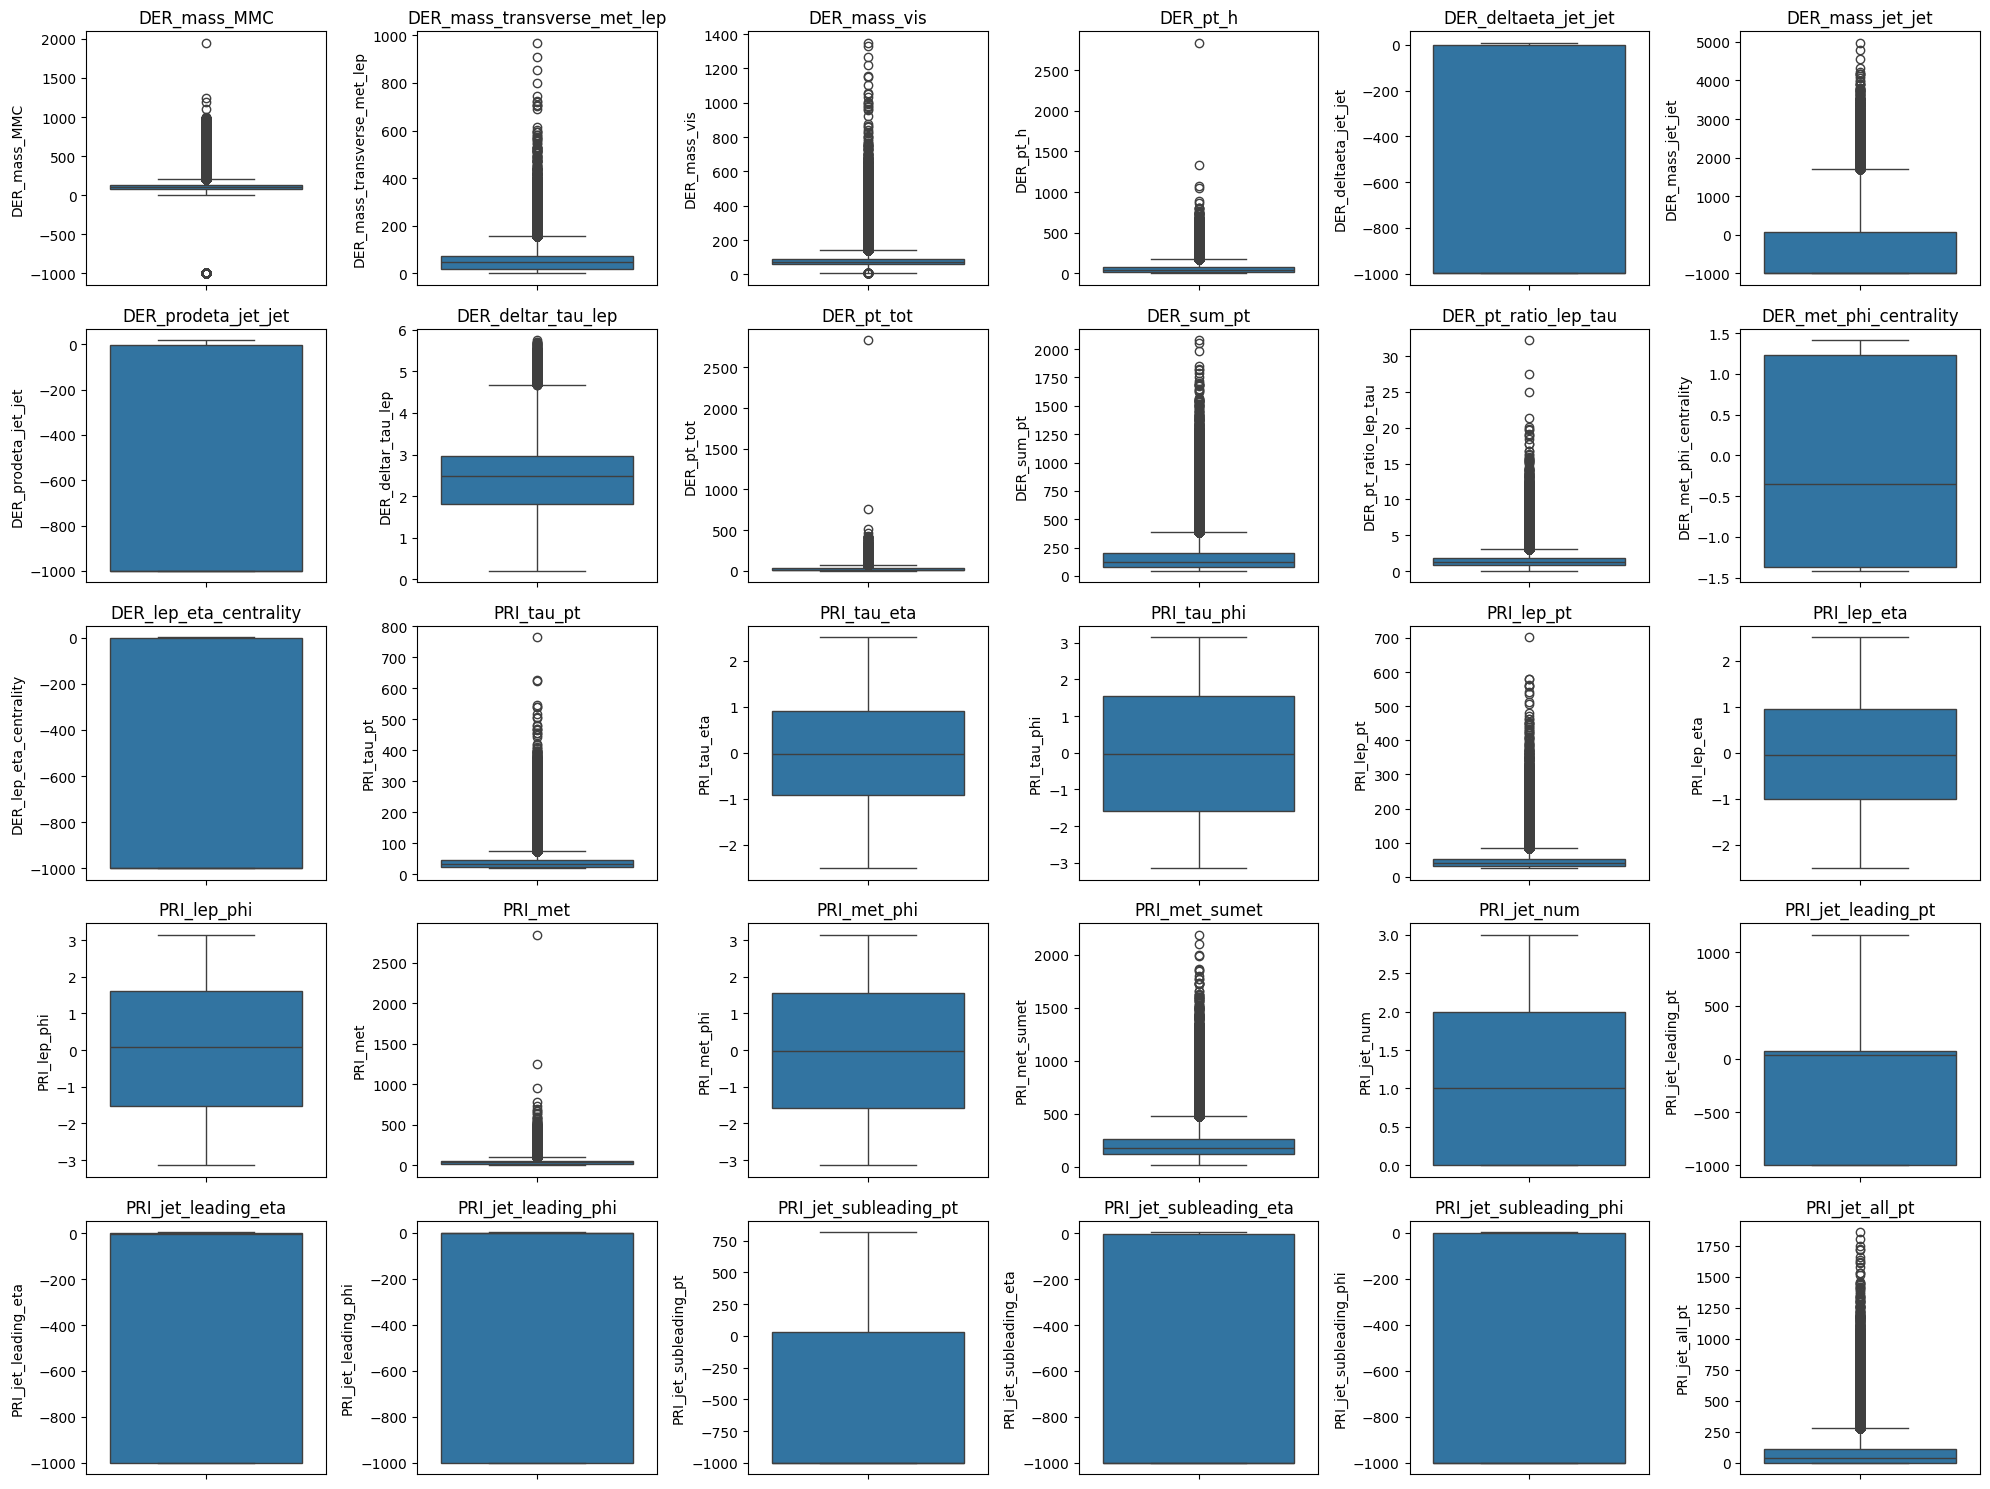

In [17]:
plt.figure(figsize=(20,15))
for i, column in enumerate(X.columns):
    plt.subplot(5, 6, i + 1)
    sns.boxplot(y=X[column])
    plt.title(column)
plt.tight_layout()
plt.show()

### 6. Check unbalanced ratio

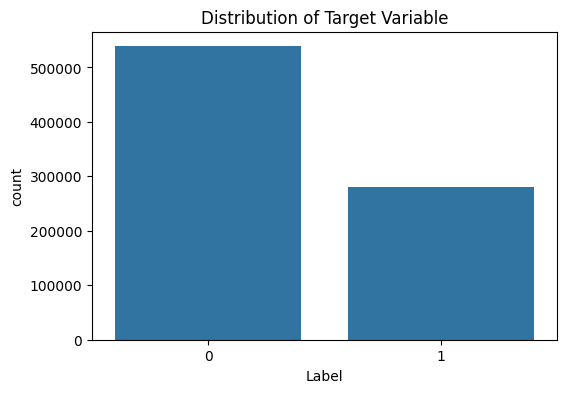

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Target Variable')
plt.show()